# **Assignment: First Round of Supervised Learning Models**:
*Michael David Gonzales*

# **Reading and Splitting the Data**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv('maintenance.csv')

# 2. Separate features (X) and target (y)
X = df.drop(columns=['Failure'])
y = df['Failure']

# 3. Perform a 70/30 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=24
)

# 4. Verify proportions
print("Training Target Proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest Target Proportions:")
print(y_test.value_counts(normalize=True))

Training Target Proportions:
Failure
0    0.77423
1    0.22577
Name: proportion, dtype: float64

Test Target Proportions:
Failure
0    0.774379
1    0.225621
Name: proportion, dtype: float64


# **Logistic Regression**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score
import statsmodels.api as sm

# --- SCIKIT-LEARN MODEL ---
log_reg = LogisticRegression(solver='liblinear', penalty='l1', C=1.0, random_state=24)
log_reg.fit(X_train, y_train)

# Display predictions and dual probabilities for the first 5 training observations
predictions = log_reg.predict(X_train[:5])
probabilities = log_reg.predict_proba(X_train[:5])

print("First 5 Training Predictions & Probabilities:")
for i in range(5):
    p0 = probabilities[i][0]
    p1 = probabilities[i][1]
    print(f"Obs {i+1}: [P(0) = {p0:.4f}, P(1) = {p1:.4f}] --> Predicted Class = {predictions[i]}")

First 5 Training Predictions & Probabilities:
Obs 1: [P(0) = 0.6131, P(1) = 0.3869] --> Predicted Class = 0
Obs 2: [P(0) = 0.2937, P(1) = 0.7063] --> Predicted Class = 1
Obs 3: [P(0) = 0.9266, P(1) = 0.0734] --> Predicted Class = 0
Obs 4: [P(0) = 0.2975, P(1) = 0.7025] --> Predicted Class = 1
Obs 5: [P(0) = 0.2993, P(1) = 0.7007] --> Predicted Class = 1


**A logistic regression model outputs a continuous probability between 0 and 1. The model outputs an array of [Probability of 0, Probability of 1] which sum to 1.0. By default, scikit-learn applies a 0.5 decision threshold: if the probability of failure (class 1) is >= 0.5, the model predicts 1 (Failure); if it is < 0.5, it predicts 0 (No Failure).**



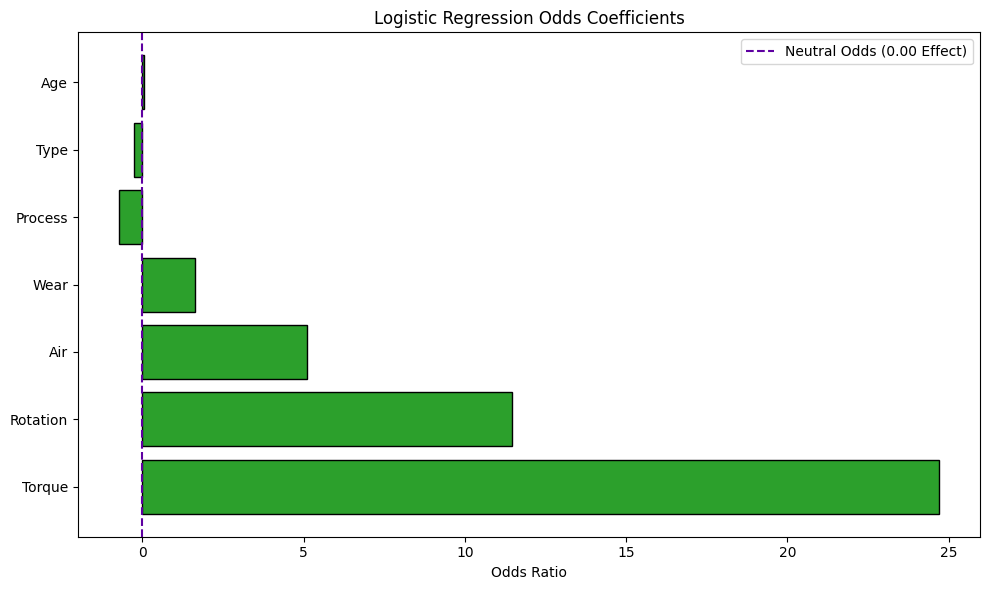

In [17]:
# Create horizontal bar plot for Odds Coefficients
odds_coef = np.exp(log_reg.coef_[0]) - 1
features = X.columns

# Sort by absolute value of the raw coefficients (which determines impact magnitude)
sort_idx = np.argsort(np.abs(odds_coef))[::-1]
sorted_features = features[sort_idx]
sorted_odds = odds_coef[sort_idx]

plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_odds, color='#2CA02C', edgecolor='black')
plt.axvline(x=0.0, color=(0.37, 0.0, 0.63), linestyle='--', label='Neutral Odds (0.00 Effect)')
plt.title('Logistic Regression Odds Coefficients')
plt.xlabel('Odds Ratio')
plt.legend()
plt.tight_layout()
plt.show()

**Based on the model coefficients, Torque has the largest absolute coefficient (highest impact), making it the most important variable in predicting failure. Age has a coefficient closest to 0 (odds ratio closest to 1.0), making it the least important variable.**

In [18]:
# --- STATSMODELS MODEL ---
np.random.seed(24)
X_train_sm = sm.add_constant(X_train)
sm_model = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(sm_model.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0441      0.069    -29.568      0.000      -2.180      -1.909
Type          -0.2817      0.073     -3.845      0.000      -0.425      -0.138
Air            1.8405      0.104     17.781      0.000       1.638       2.043
Process       -1.3067      0.100    -13.124      0.000      -1.502      -1.112
Rotation       2.5482      0.090     28.375      0.000       2.372       2.724
Age            0.0446      0.045      0.982      0.326      -0.044       0.134
Torque         3.2771      0.102     32.202      0.000       3.078       3.477
Wear           0.9776      0.052     18.938      0.000       0.876       1.079


**Looking at the P>|z| column, the Age feature has a p-value of roughly 0.326. Because this is significantly higher than the standard 0.05 alpha threshold, it is not statistically significant and would be the primary candidate for removal to improve the model.**

In [19]:
# --- EVALUATION METRICS ---
train_preds = log_reg.predict(X_train)
test_preds = log_reg.predict(X_test)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
kappa = cohen_kappa_score(y_test, test_preds)
baseline_acc = (y_test == 0).mean()

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Cohen's Kappa:     {kappa:.4f}")
print(f"Baseline Accuracy (No Info Model): {baseline_acc:.4f}")

Training Accuracy: 0.8759
Test Accuracy:     0.8679
Cohen's Kappa:     0.5906
Baseline Accuracy (No Info Model): 0.7744


**The training accuracy is 87.59% and the test accuracy is 86.79%. Because the training and test scores are nearly identical (a difference of less than 1%), there is no evidence of overfitting; the model generalizes well to unseen data.**

**Furthermore, the test Cohen's Kappa score is 0.5906, which indicates moderate-to-substantial agreement above chance. Since a "no information" baseline model has a Cohen's Kappa of 0.0 (and an accuracy of only 77.44%), our model performs significantly better than the baseline.**

# **Naive Bayes**

Naive Bayes AUC Score: 0.8925


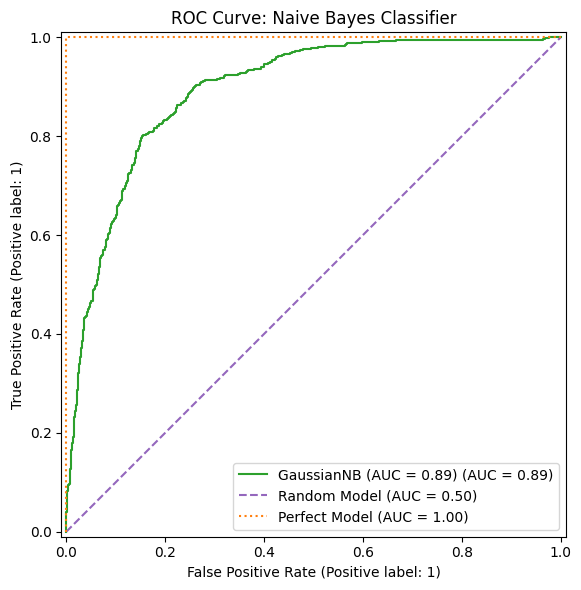

In [20]:
# --- NAIVE BAYES MODEL ---
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, RocCurveDisplay

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_probs = nb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, nb_probs)
print(f"Naive Bayes AUC Score: {auc_score:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    nb_model, X_test, y_test,
    color='#2CA02C',
    linestyle='-',
    name=f'GaussianNB (AUC = {auc_score:.2f})',
    ax=ax
)

# Random model (hex color and dashed style)
ax.plot([0, 1], [0, 1], color='#9467BD', linestyle='--', label='Random Model (AUC = 0.50)')

# Perfect model (hex color and dotted style)
ax.plot([0, 0, 1], [0, 1, 1], color='#FF7F0E', linestyle=':', label='Perfect Model (AUC = 1.00)')

plt.title('ROC Curve: Naive Bayes Classifier')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Based on the AUC score of roughly 0.89, the Naive Bayes model performed very well. An AUC of 1.0 represents a perfect model, and 0.50 represents random guessing. At 0.89, the model demonstrates strong discriminative ability in distinguishing failures from non-failures across decision thresholds.**

# **KNN**

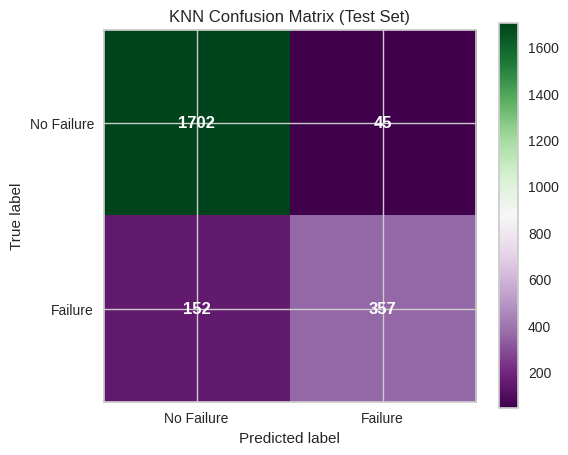

=== Sklearn Classification Report ===
              precision    recall  f1-score   support

  No Failure      0.918     0.974     0.945      1747
     Failure      0.888     0.701     0.784       509

    accuracy                          0.913      2256
   macro avg      0.903     0.838     0.865      2256
weighted avg      0.911     0.913     0.909      2256



In [22]:
# --- K-NEAREST NEIGHBORS (KNN) ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from yellowbrick.classifier import ClassificationReport

# Fit KNN model using the test set, n_neighbors=10, and KDTree
knn_model = KNeighborsClassifier(n_neighbors=10, algorithm='kd_tree')
knn_model.fit(X_test, y_test)

# Confusion Matrix with colorbar and custom labels
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    knn_model, X_test, y_test,
    display_labels=["No Failure", "Failure"],
    cmap='PRGn',
    text_kw={'color': 'white', 'weight': 'bold'},  # Make text bold and white
    ax=ax
)
plt.title('KNN Confusion Matrix (Test Set)')
plt.show()

# Sklearn Classification Report (3 decimal places)
print("=== Sklearn Classification Report ===")
print(classification_report(y_test, knn_model.predict(X_test), target_names=["No Failure", "Failure"], digits=3))

**According to the confusion matrix, the model produced 357 true positives and 152 false negatives. The total number of failures (1s) predicted by this model on the test set is 402 (357 true positives + 45 false positives).**

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


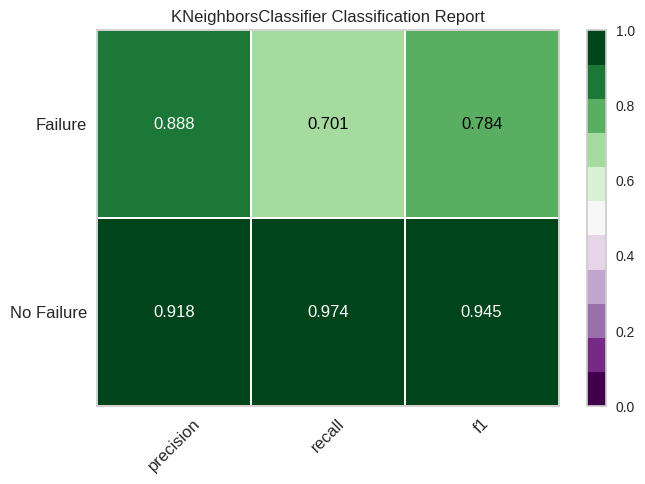

<Axes: title={'center': 'KNeighborsClassifier Classification Report'}>

In [23]:
# Create the Classification Report using Yellowbrick
fig, ax = plt.subplots(figsize=(7, 5))

# Initialize the visualizer, hiding the support column
visualizer = ClassificationReport(
    knn_model,
    classes=["No Failure", "Failure"],
    cmap="PRGn",  # Sequential color palette (Yellow-Green-Blue)
    support=False,
    ax=ax
)

# Fit, score, and show the report (rounded to 3 decimal places by default)
visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

**Based on the classification report, the KNN model achieved a precision of 0.888, a recall of 0.701, and an F1-score of 0.784 for the Failure class, while achieving a precision of 0.918, a recall of 0.974, and an F1-score of 0.945 for the No Failure class.**

# **Sampling**

In [24]:
# --- ADDRESSING IMBALANCE: SAMPLING ---
from sklearn.utils import resample

# 1. Display original target counts and proportions
print("Original Target Counts (Before Split):")
print(df['Failure'].value_counts())
print("\nOriginal Target Proportions (Before Split):")
print(df['Failure'].value_counts(normalize=True))

# Separate the majority and minority classes from the ORIGINAL dataframe
df_majority = df[df['Failure'] == 0]
df_minority = df[df['Failure'] == 1]

# 2. Undersampling
df_majority_undersampled = resample(
    df_majority,
    replace=False,    # sample without replacement
    n_samples=len(df_minority), # to match minority class
    random_state=24
)
# Combine minority class with downsampled majority class
df_undersampled = pd.concat([df_majority_undersampled, df_minority])

print("\nUndersampling Proportions:")
print(df_undersampled['Failure'].value_counts(normalize=True))
print("Undersampling Counts:")
print(df_undersampled['Failure'].value_counts())

# 3. Oversampling
df_minority_oversampled = resample(
    df_minority,
    replace=True,     # sample with replacement (bootstrap)
    n_samples=len(df_majority), # to match majority class
    random_state=24
)
# Combine majority class with upsampled minority class
df_oversampled = pd.concat([df_majority, df_minority_oversampled])

print("\nOversampling Proportions:")
print(df_oversampled['Failure'].value_counts(normalize=True))
print("Oversampling Counts:")
print(df_oversampled['Failure'].value_counts())

Original Target Counts (Before Split):
Failure
0    5821
1    1697
Name: count, dtype: int64

Original Target Proportions (Before Split):
Failure
0    0.774275
1    0.225725
Name: proportion, dtype: float64

Undersampling Proportions:
Failure
0    0.5
1    0.5
Name: proportion, dtype: float64
Undersampling Counts:
Failure
0    1697
1    1697
Name: count, dtype: int64

Oversampling Proportions:
Failure
0    0.5
1    0.5
Name: proportion, dtype: float64
Oversampling Counts:
Failure
0    5821
1    5821
Name: count, dtype: int64


**Based on this output, the target classes are imbalanced: approximately 77.4% of the records represent class 0 (No Failure) and only 22.6% represent class 1 (Failure).**

**Balancing target classes prevents a model from simply learning to predict the majority class to achieve an artificially high accuracy score. Undersampling is useful for extremely large datasets but risks discarding valuable information from the majority class. Oversampling retains all information but relies on duplicating existing minority records, which can lead to overfitting on those specific repeated examples.**

**I prefer oversampling because this dataset contains only ~7,500 rows. Undersampling would discard over 4,000 majority-class observations and erase crucial variance, whereas oversampling preserves the full distribution of the feature space.**